# Model building 

### Load Library 

In [46]:
import pandas as pd 
import numpy as np
import joblib 
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, classification_report,confusion_matrix

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier


### Splitting the histrorical dataset 80/20

In [2]:
#load the data
path = "/Users/sivhoung/Fraud_detection/historical_data/part-00000-afbc1c86-0307-4cb4-96a5-8db1604ed007-c000.csv"
df = pd.read_csv(path)

In [3]:
#filter the data
high_risk_types = ['TRANSFER', 'CASH_OUT']
df_filtered = df[df['type'].isin(high_risk_types)].copy()

In [13]:
df_filtered.head(5)

,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,transaction_timestamp
94136,CASH_OUT,1.58,C336054500,0.00,0.00,C204086290,197938.48,70090.20,0,0,2026-01-01T09:00:00.000+07:00
94137,CASH_OUT,10.64,C970493889,0.00,0.00,C15992934,261409.23,261419.87,0,0,2026-01-01T15:00:00.000+07:00
94138,CASH_OUT,11.83,C183417696,4251056.28,4251044.45,C1742712270,16497.52,807208.69,0,0,2026-01-01T08:00:00.000+07:00
94139,CASH_OUT,15.37,C1775637065,0.00,0.00,C1954345491,28630.58,28645.96,0,0,2026-01-01T13:00:00.000+07:00
94140,CASH_OUT,17.35,C497821095,0.00,0.00,C621810262,5339840.10,5640268.32,0,0,2026-01-01T18:00:00.000+07:00


In [20]:
#check the data 
print(df_filtered.info())
print(df_filtered.describe())
print(df_filtered['isfraud'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 2216200 entries, 94136 to 5090064
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   type                   object 
 1   amount                 float64
 2   nameorig               object 
 3   oldbalanceorg          float64
 4   newbalanceorig         float64
 5   namedest               object 
 6   oldbalancedest         float64
 7   newbalancedest         float64
 8   isfraud                int64  
 9   isflaggedfraud         int64  
 10  transaction_timestamp  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 202.9+ MB
None
             amount  oldbalanceorg  newbalanceorig  oldbalancedest  \
count  2.216200e+06   2.216200e+06    2.216200e+06    2.216200e+06   
mean   3.178607e+05   4.758410e+04    1.605038e+04    1.703971e+06   
std    8.890796e+05   2.527459e+05    1.524004e+05    4.207352e+06   
min    0.000000e+00   0.000000e+00    0.000000e+00    0.000000e+00   
2

In [24]:
# Split the data into features and target variable 
x = df_filtered.drop('isfraud', axis =1)
y = df_filtered['isfraud']

x_train,x_test,y_train, y_test = train_test_split(
    x,y,test_size =0.2, stratify = y, random_state=42
)

In [25]:
#check the distribution of the dataset after splitting
print("Distribution of target variable in training set:")
print(y_train.value_counts())
print("\nDistribution of target variable in test set:")
print(y_test.value_counts())

Distribution of target variable in training set:
isfraud
0    1767681
1       5279
Name: count, dtype: int64

Distribution of target variable in test set:
isfraud
0    441920
1      1320
Name: count, dtype: int64


In [28]:
print(df_filtered.columns)

Index(['type', 'amount', 'nameorig', 'oldbalanceorg', 'newbalanceorig',
       'namedest', 'oldbalancedest', 'newbalancedest', 'isfraud',
       'isflaggedfraud', 'transaction_timestamp'],
      dtype='object')


In [31]:
#row by row feature engineering 
print("\nStep 3: Engineering row-by-row core features...")

def add_custom_features(data):
    df_out = data.copy()
    # 发起方余额变动异常特征
    df_out['errorBalanceorig'] = df_out['newbalanceorig'] + df_out['amount'] - df_out['oldbalanceorg']
    # 接收方余额变动异常特征
    df_out['errorBalancedest'] = df_out['newbalancedest'] - df_out['oldbalancedest']
    
    # 顺便删除对欺诈分类毫无数学意义的字符串标识列（防止后续算法报错）
    df_out = df_out.drop(['nameorig', 'namedest'], axis=1)
    if 'step' in df_out.columns:
        df_out = df_out.drop(['step'], axis=1) # step通常作为时间步，可根据需要保留或去除
    return df_out

X_train_featured = add_custom_features(x_train)
X_test_featured = add_custom_features(x_test)


Step 3: Engineering row-by-row core features...


In [34]:
#encoding the feature 
print("\nStep 4: Performing One-Hot Encoding for 'type'...")
X_train_encoded = pd.get_dummies(X_train_featured, columns=['type'], dtype=int)
X_test_encoded = pd.get_dummies(X_test_featured, columns=['type'], dtype=int)

# 黄金保险：确保训练集和验证集的特征列和顺序完全一模一样，防止缺失或错位
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

X_train_encoded = X_train_encoded.select_dtypes(include=[np.number])
X_test_encoded = X_test_encoded.select_dtypes(include=[np.number])


Step 4: Performing One-Hot Encoding for 'type'...


### Dealing with imbalance data using SMOTE (train data)
SMOTE (Synthetic Minority Over-sampling Technique) is a popular machine learning algorithm used to address class imbalance in datasets. It creates artificial (synthetic) examples of the minority class using interpolation, allowing models to learn broader patterns without overfitting to exact copies of existing data.

In [ ]:
#applying global aggregations and SMOTE (strickly isolatied)
#standardize the data ( for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Before SMOTE - Train labels distribution: {np.bincount(y_train)}")

Before SMOTE - Train labels distribution: [1767681    5279]


In [37]:
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Resampled Train labels distribution: {np.bincount(y_train_resampled)}")


After SMOTE - Resampled Train labels distribution: [1767681 1767681]


# Model training 

In [43]:
#initialize the 3 cadidate modles
models ={
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42,n_jobs =-1),
    "Random_Forest": RandomForestClassifier(max_depth = 14,n_estimators=100, random_state = 42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
}

In [45]:
comparison_metrics ={}

Starting model training and evaluation
Training model [1/3]:Logistic_Regression:


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linea

Logistic_Regression training completed in 3.55 seconds.
Classification Report for Logistic_Regression:
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97    441920
       Fraud       0.05      0.94      0.09      1320

    accuracy                           0.94    443240
   macro avg       0.52      0.94      0.53    443240
weighted avg       1.00      0.94      0.97    443240

Training model [2/3]:Random_Forest:


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Random_Forest training completed in 60.76 seconds.
Classification Report for Random_Forest:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    441920
       Fraud       0.94      1.00      0.97      1320

    accuracy                           1.00    443240
   macro avg       0.97      1.00      0.99    443240
weighted avg       1.00      1.00      1.00    443240

Training model [3/3]:XGBoost:
XGBoost training completed in 2.01 seconds.
Classification Report for XGBoost:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    441920
       Fraud       0.82      0.99      0.90      1320

    accuracy                           1.00    443240
   macro avg       0.91      1.00      0.95    443240
weighted avg       1.00      1.00      1.00    443240



<function matplotlib.pyplot.show(close=None, block=None)>

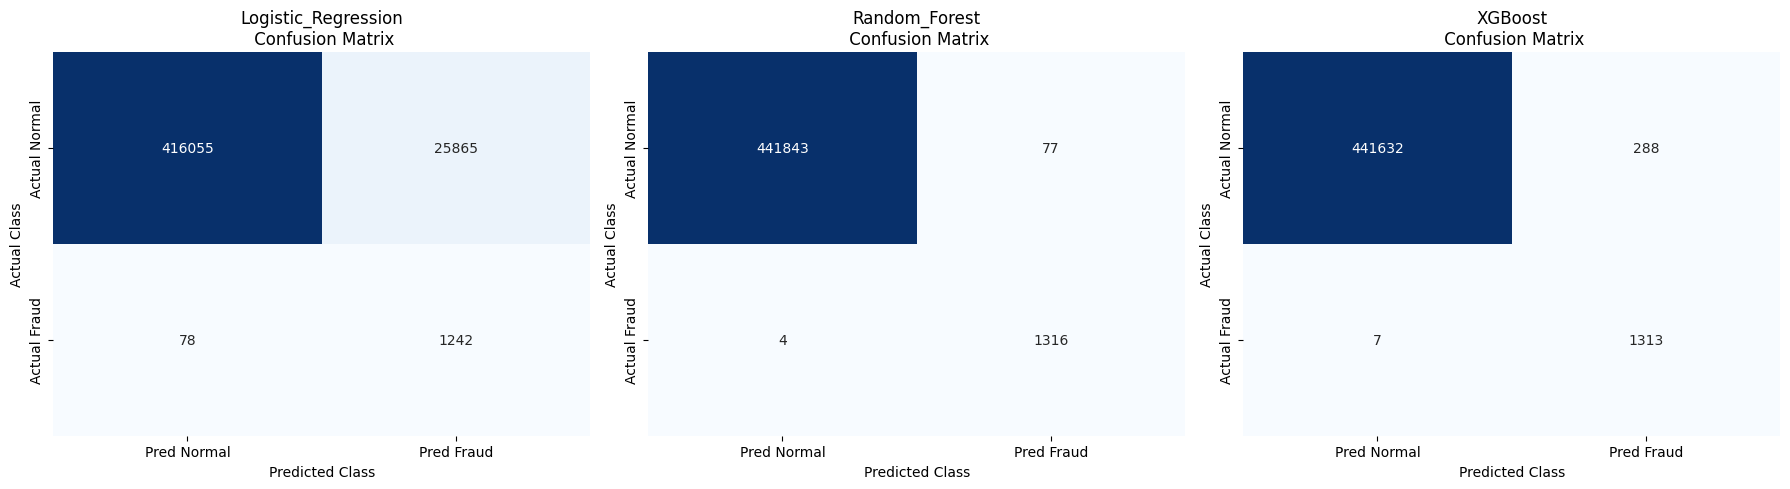

In [48]:
print("Starting model training and evaluation")

#setup matplotlib figure for side-by-side  confusion matrix visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx,(model_name, model_obj) in enumerate(models.items()):
    print(f"Training model [{idx+1}/{len(models)}]:{model_name}:")

    #train the model with SMOTE-balanced data
    start_time = time.time()
    model_obj.fit(x_train_resampled,y_train_resampled)
    elapsed_time = time.time()-start_time
    print(f"{model_name} training completed in {elapsed_time:.2f} seconds.")

    #predict on the isolated, unpolluted test set
    y_pred = model_obj.predict(X_test_scaled)
    y_pred_proba = model_obj.predict_proba(X_test_scaled)[:,1]

    #calculate key performance indicators 
    # since fraud detection is highly imbalanced, we focus on positive class (1=fraud)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test,y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test,y_pred)

    #store metrics in the comparison dictionary 
    comparison_metrics[model_name] = {
        "Recall (Fraud)":f"{rec:.2%}",
        "Precision (Fraud)": f"{prec:.2%}",
        "F1-Score":f'{f1:.2%}',
        "Roc-Auc":f"{auc:.2%}",
        "Training Time(s)":f"{elapsed_time:.2f}s"
    }
    #print standard test classification report 
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred,target_names=["Normal",'Fraud']))

    #Plot the confusion matrix for this model onto the subplot axis
    cm = confusion_matrix(y_test,y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],cbar=False,
                xticklabels=["Pred Normal",'Pred Fraud'],
                yticklabels=['Actual Normal','Actual Fraud']
                )
    axes[idx].set_title(f'{model_name}\n Confusion Matrix')
    axes[idx].set_ylabel('Actual Class')
    axes[idx].set_xlabel('Predicted Class')

plt.tight_layout()
plt.show


In [50]:
# Convert the comparison dictionary into a clean, presentation-ready DataFrame
df_comparison = pd.DataFrame(comparison_metrics).T
print("FINAL MODEL PERFORMANCE COMPARISON MATRIX:")
print("==================================================================")
print(df_comparison)

FINAL MODEL PERFORMANCE COMPARISON MATRIX:
                    Recall (Fraud) Precision (Fraud) F1-Score Roc-Auc  \
Logistic_Regression         94.09%             4.58%    8.74%  94.12%   
Random_Forest               99.70%            94.47%   97.01%  99.84%   
XGBoost                     99.47%            82.01%   89.90%  99.70%   

                    Training Time(s)  
Logistic_Regression            3.55s  
Random_Forest                 60.76s  
XGBoost                        2.01s  


### Automatically exporting the best performing model 

In [53]:
#Convert formatted percentages back to floats to find the maximum Recall
rec_scores = {name: float(metrics["Recall (Fraud)"].replace('%','')) for name, metrics in comparison_metrics.items()}
best_model_name = max(rec_scores, key=rec_scores.get)

print(f'The best performing model is: {best_model_name} ({rec_scores[best_model_name]:.2f}%)')

The best performing model is: Random_Forest (99.70%)


In [57]:
#save the best model
best_model_obj = models[best_model_name]
joblib.dump(best_model_obj,'best_fraud_detection_model.pkl')
print(f"Export complete! Saved '{best_model_name}' as 'best_fraud_detection_model.pkl'.")

Export complete! Saved 'Random_Forest' as 'best_fraud_detection_model.pkl'.


In [58]:
joblib.dump(scaler, 'preprocessing_scaler.pkl')

['preprocessing_scaler.pkl']